In [4]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [6]:
#!pip install pytorch-forecasting

In [7]:
#import torch
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [8]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

In [9]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [10]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

In [13]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [14]:

def prepare_tft_df(df: pd.DataFrame, time_col="open_time", group_col="symbol"):
    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col])
    d = d.sort_values([group_col, time_col]).reset_index(drop=True)

    d["time_idx"] = d.groupby(group_col).cumcount()

    d["hour"] = d[time_col].dt.hour
    d["dayofweek"] = d[time_col].dt.dayofweek
    d["day"] = d[time_col].dt.day

    return d

In [15]:
def fit_tft_anomaly(
    df: pd.DataFrame,
    target="log_return",
    time_idx="time_idx",
    time_col="open_time",
    group_ids=["symbol"],
    known_reals=["hour", "dayofweek", "day"],
    observed_reals=None,
    encoder_len=96,
    pred_len=12,
    batch_size=256,
    max_epochs=8
):
    d = prepare_tft_df(df, time_col=time_col, group_col=group_ids[0])

    if observed_reals is None:
        observed_reals = ["volatility_20", "range_hl", "trades_per_volume", "buy_ratio"]

    needed = [target] + known_reals + observed_reals + [time_idx] + group_ids + [time_col]
    d = d.dropna(subset=needed).copy()

    max_idx = d[time_idx].max()
    cutoff = int(max_idx * 0.8)

    train_df = d[d[time_idx] <= cutoff]
    val_df   = d[d[time_idx] > cutoff]

    training = TimeSeriesDataSet(
        train_df,
        time_idx=time_idx,
        target=target,
        group_ids=group_ids,
        max_encoder_length=encoder_len,
        max_prediction_length=pred_len,
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=[target] + observed_reals,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(training, val_df, stop_randomization=True)

    train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_loader   = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=16,
        output_size=3,
        loss=QuantileLoss([0.1, 0.5, 0.9]),
        reduce_on_plateau_patience=3,
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, mode="min"),
        LearningRateMonitor(logging_interval="epoch")
    ]

    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices="auto",
        gradient_clip_val=0.1,
        callbacks=callbacks,
        log_every_n_steps=50,
        enable_checkpointing=False,   # para evitar líos de paths al inicio
    )

    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

    return tft, training, validation, d

In [16]:
def score_tft_anomalies(
    model,
    dataset,
    df_full,
    target="log_return"
):
    
    loader = dataset.to_dataloader(train=False, batch_size=512, num_workers=0)

    preds = model.predict(loader, mode="quantiles")

    qlo = preds[..., 0]
    qmed = preds[..., 1]
    qhi = preds[..., 2]

    # usamos horizonte 1 (t+1)
    qlo_1 = qlo[:, 0]
    qmed_1 = qmed[:, 0]
    qhi_1 = qhi[:, 0]

    # usamos el dataframe original
    out = df_full.iloc[-len(qlo_1):].copy()

    out["tft_q10"] = qlo_1
    out["tft_q50"] = qmed_1
    out["tft_q90"] = qhi_1

    out["tft_anomaly"] = (
        (out[target] < out["tft_q10"]) |
        (out[target] > out["tft_q90"])
    ).astype(int)

    out["tft_score"] = np.where(
        out[target] > out["tft_q90"], out[target] - out["tft_q90"],
        np.where(out[target] < out["tft_q10"], out["tft_q10"] - out[target], 0.0)
    )

    return out

In [17]:
def plot_tft_anomalies(df_scored, time_col="open_time", target="log_return"):
    d = df_scored.sort_values(time_col).copy()

    plt.figure(figsize=(14,6))
    plt.plot(d[time_col], d[target], label=target, alpha=0.7)

    an = d[d["tft_anomaly"] == 1]
    plt.scatter(an[time_col], an[target],
                label="Anomalías (TFT)",
                s=25,
                color="red")

    plt.title("Anomalías detectadas con TFT (por cuantiles)")
    plt.xlabel("Tiempo")
    plt.ylabel(target)
    plt.legend()
    plt.show()

In [18]:
def plot_tft_interval_anomalies(df, time_col="open_time", y_col="log_return",
                                q10="tft_q10", q50="tft_q50", q90="tft_q90",
                                anomaly_col="tft_anomaly", title="TFT: Intervalo predictivo y anomalías"):
    d = df.dropna(subset=[y_col, q10, q50, q90]).copy()
    if time_col in d.columns:
        x = d[time_col]
    else:
        x = d.index

    plt.figure(figsize=(14,6))
    plt.plot(x, d[y_col], label=f"Real ({y_col})", alpha=0.7)
    plt.plot(x, d[q50], label="Predicción (q50)", alpha=0.9)

    # banda
    plt.fill_between(x, d[q10], d[q90], alpha=0.2, label="Intervalo (q10–q90)")

    # anomalías
    an = d[d[anomaly_col] == 1]
    plt.scatter(an[time_col] if time_col in d.columns else an.index, an[y_col],
                s=25, color="darkorange", label="Anomalía")

    plt.title(title)
    plt.legend()
    plt.show()

In [19]:
def plot_tft_residuals(df, time_col="open_time", y_col="log_return",
                       pred_col="tft_q50", anomaly_col="tft_anomaly",
                       title="TFT: Residuales y anomalías"):
    d = df.dropna(subset=[y_col, pred_col]).copy()
    d["residual"] = d[y_col] - d[pred_col]

    x = d[time_col] if time_col in d.columns else d.index

    plt.figure(figsize=(14,4))
    plt.plot(x, d["residual"], label="Residual (real - pred)", alpha=0.8)

    an = d[d[anomaly_col] == 1]
    plt.scatter(an[time_col] if time_col in d.columns else an.index, an["residual"],
                s=25, color="darkorange", label="Anomalía")

    plt.axhline(0, linewidth=1)
    plt.title(title)
    plt.legend()
    plt.show()

In [20]:
def evaluar_isolation_forest(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

In [27]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [21]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [22]:
df_clean = df.copy()

# 1) quitar inf
df_clean[features] = df_clean[features].replace([np.inf, -np.inf], np.nan)

# 2) eliminar filas con NA en features
df_clean = df_clean.dropna(subset=features).reset_index(drop=True)

In [23]:
tft_model, train_ds, val_ds, df_tft = fit_tft_anomaly(
    df=df_clean,
    encoder_len=96,
    pred_len=12,
    max_epochs=8,
    batch_size=256
)

c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosy

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 6: 100%|██████████| 878/878 [18:20:48<00:00,  0.01it/s, v_num=6, train_loss_step=0.00145, val_loss=0.00108, train_loss_epoch=0.00152]   


In [24]:
df_scored_tft = score_tft_anomalies(
    model=tft_model,
    dataset=val_ds,
    df_full=df_tft,
    target="log_return"
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\cecil\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_wor

In [25]:
print(df_scored_tft.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'n_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'symbol', 'interval', 'log_return', 'volatility_20',
       'range_hl', 'trades_per_volume', 'buy_ratio', 'z_return',
       'anomaly_simple', 'time_idx', 'hour', 'dayofweek', 'day', 'tft_q10',
       'tft_q50', 'tft_q90', 'tft_anomaly', 'tft_score'],
      dtype='object')


In [26]:
metrics_TFT = evaluar_modelo(
    df_result=df_scored_tft,
    anomaly_col='tft_anomaly',
    score_col='tft_score',
    zscore_col="anomaly_simple"
)

print(metrics_TFT)

   total_observaciones  total_anomalias  anomaly_rate  score_media  score_std  \
0                56113            11009      0.196193     0.000315   0.001204   

   score_min  score_p50  score_p95  score_p99  score_max  \
0        0.0        0.0    0.00193   0.005525   0.040631   

   zscore_total_anomalias  overlap_zscore_n  overlap_zscore_pct  
0                     276               273             0.98913  


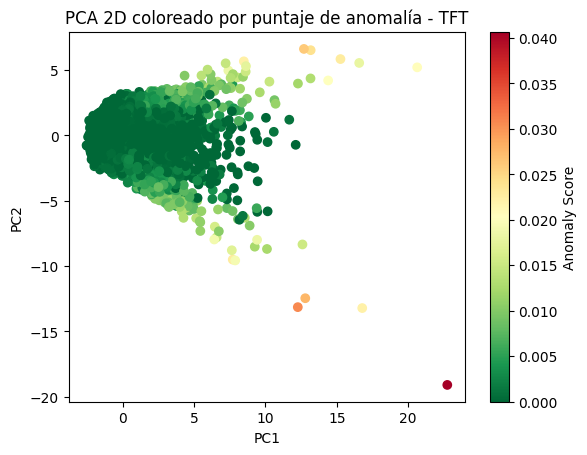

In [28]:
plot_pca_score(
    df=df_scored_tft,
    features=features,
    score_col='tft_score',
    title="PCA 2D coloreado por puntaje de anomalía - TFT"
)

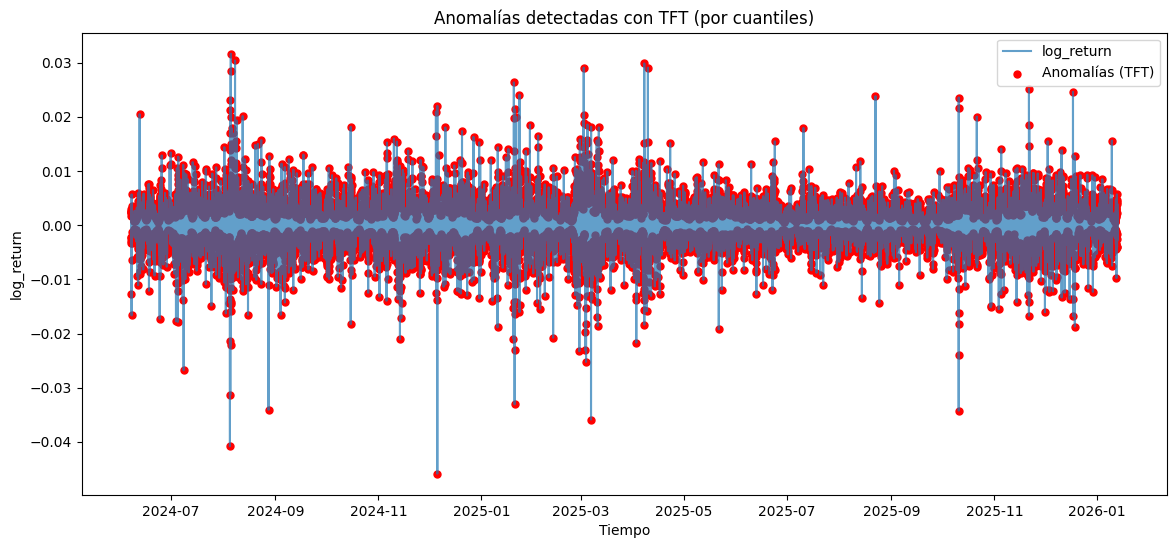

In [29]:
plot_tft_anomalies(df_scored_tft, time_col="open_time", target="log_return")

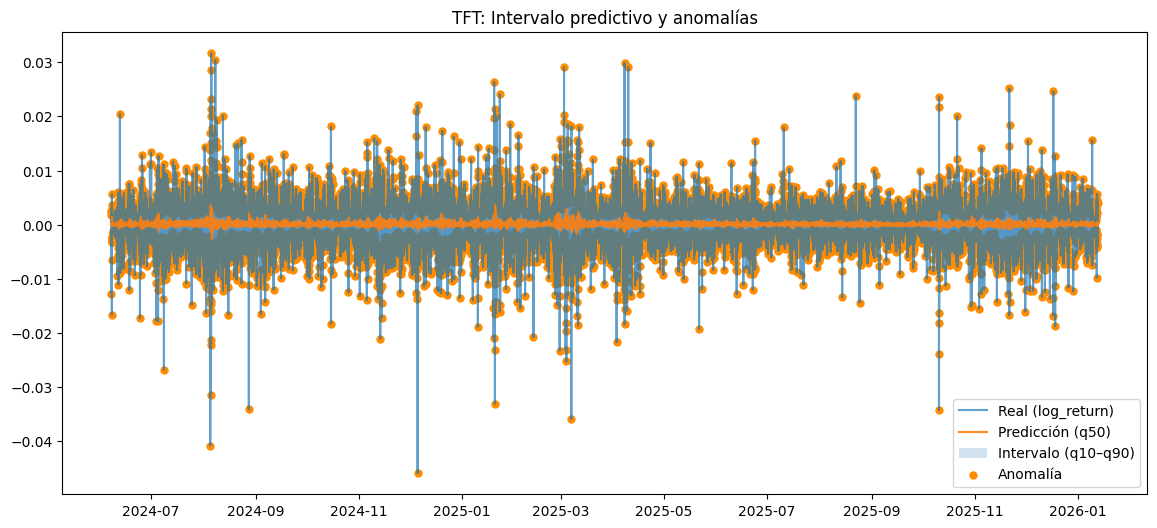

In [30]:
plot_tft_interval_anomalies(df_scored_tft, time_col="open_time", y_col="log_return")

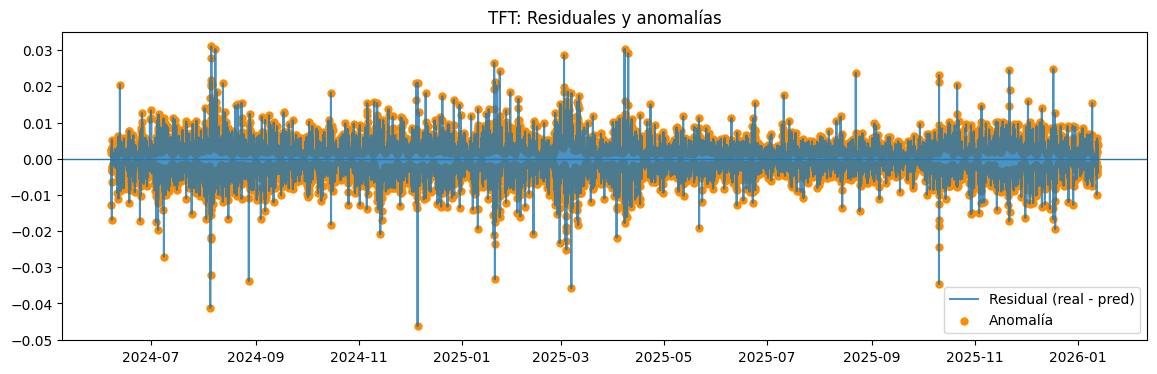

In [31]:
plot_tft_residuals(df_scored_tft, time_col="open_time")